#Regression


###1.Choosing a Dataset


In [ ]:
#-------------------IMPORTS-----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/Final assignment/train.csv")

# Metadata Analysis
print("=== Dataset Metadata ===")
print(f"(a) Created by: TJ Klein (Kaggle contributor, 2020)")
print(f"(b) Accessed from: Kaggle (https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)")
print(f"(c) SDG 9: Industry, Innovation, and Infrastructure")
print("   Relevance: Predicting flight delays improves airline efficiency, reducing fuel waste and infrastructure strain.")
print("\n(d) Attributes:", list(df.columns))

print("\n=== Key Questions ===")
print("- How do operational factors (e.g., departure delay, flight distance) affect arrival delay times?")
print("- Can we predict arrival delay duration (in minutes) using flight operational data?")

# Suitability Assessment
print("\n=== Data Suitability ===")
print(f"Missing Values (Arrival Delay): {df['Arrival Delay in Minutes'].isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Target Variable Skewness: {df['Arrival Delay in Minutes'].skew():.2f}")


=== Dataset Metadata ===
(a) Created by: TJ Klein (Kaggle contributor, 2020)
(b) Accessed from: Kaggle (https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)
(c) SDG 9: Industry, Innovation, and Infrastructure
   Relevance: Predicting flight delays improves airline efficiency, reducing fuel waste and infrastructure strain.

(d) Attributes: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

=== Key Questions ===
- How do operational factors (e.g., departure delay, flight distance) affect arrival delay times?
- Can we predict arrival delay duration (i

###2. Exploratory Data Analysis(EDA)

In [ ]:
# =====================================
# Data Cleaning
# =====================================
# Step 1: Copy data
df_clean = df.copy()

# Step 2: Handle missing values in target variable (Arrival Delay)
median_delay = df_clean['Arrival Delay in Minutes'].median()
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(median_delay)

# Step 3: Handle missing values in other numerical features
# Identify numerical features (excluding target)
numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
if 'Arrival Delay in Minutes' in numerical_features:
    numerical_features.remove('Arrival Delay in Minutes')
if 'Unnamed: 0' in numerical_features:  # Remove index column if present
    numerical_features.remove('Unnamed: 0')
if 'id' in numerical_features:
    numerical_features.remove('id') #Remove 'id' before scaling

# Impute missing values in numerical features using median
for col in numerical_features:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed missing values in column '{col}' using median.")

# Step 4: Drop irrelevant columns for regression (e.g., satisfaction, id)
df_clean = df_clean.drop(columns=['satisfaction', 'id'], errors='ignore')  # 'errors=ignore' in case 'id' isn't present

# Step 5: Encode categorical variables (e.g., Gender, Class, Type of Travel)
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# Optional Step 6: Scale numerical features to prevent overflow errors
scaler = StandardScaler()
df_clean[numerical_features] = scaler.fit_transform(df_clean[numerical_features])

# Step 7: Final checks for missing values
print("\n=== Final Data Check ===")
print("Missing Values (Target):", df_clean['Arrival Delay in Minutes'].isna().sum())
print("Feature Shape:", df_clean.shape)

print("\n=== Missing Values in All Columns AFTER Imputation ===")
print(df_clean.isnull().sum())  # Check for missing values in all columns
print("Total Missing Values:", df_clean.isnull().sum().sum())  # Verify total is 0

# Display first few rows to confirm structure
df_clean.head()


=== Final Data Check ===
Missing Values (Target): 0
Feature Shape: (103904, 28)

=== Missing Values in All Columns AFTER Imputation ===
Unnamed: 0                           0
Age                                  0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
Gender_Female                        0
Gender_Male                          0
Customer Type_Loyal Customer         0
Custo

,Unnamed: 0,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,-1.745279,-0.731539,0.203579,0.616172,0.173776,-1.547323,1.352264,-0.185532,1.183099,...,18.0,False,True,True,False,False,True,False,False,True
1,1,-0.951360,-0.957184,0.203579,-0.695245,0.173776,0.018094,-1.656326,-0.185532,-1.849315,...,6.0,False,True,False,True,True,False,True,False,False
2,2,-0.885200,-0.047584,-0.549533,-0.695245,-0.541060,-0.764614,1.352264,1.296496,1.183099,...,0.0,True,False,True,False,True,False,True,False,False
3,3,-0.951360,-0.629246,-0.549533,1.271880,1.603448,1.583511,-0.904178,-0.926545,-1.091211,...,9.0,True,False,True,False,True,False,True,False,False
4,4,1.430397,-0.978244,0.203579,-0.039537,0.173776,0.018094,0.600117,1.296496,1.183099,...,0.0,False,True,True,False,True,False,True,False,False


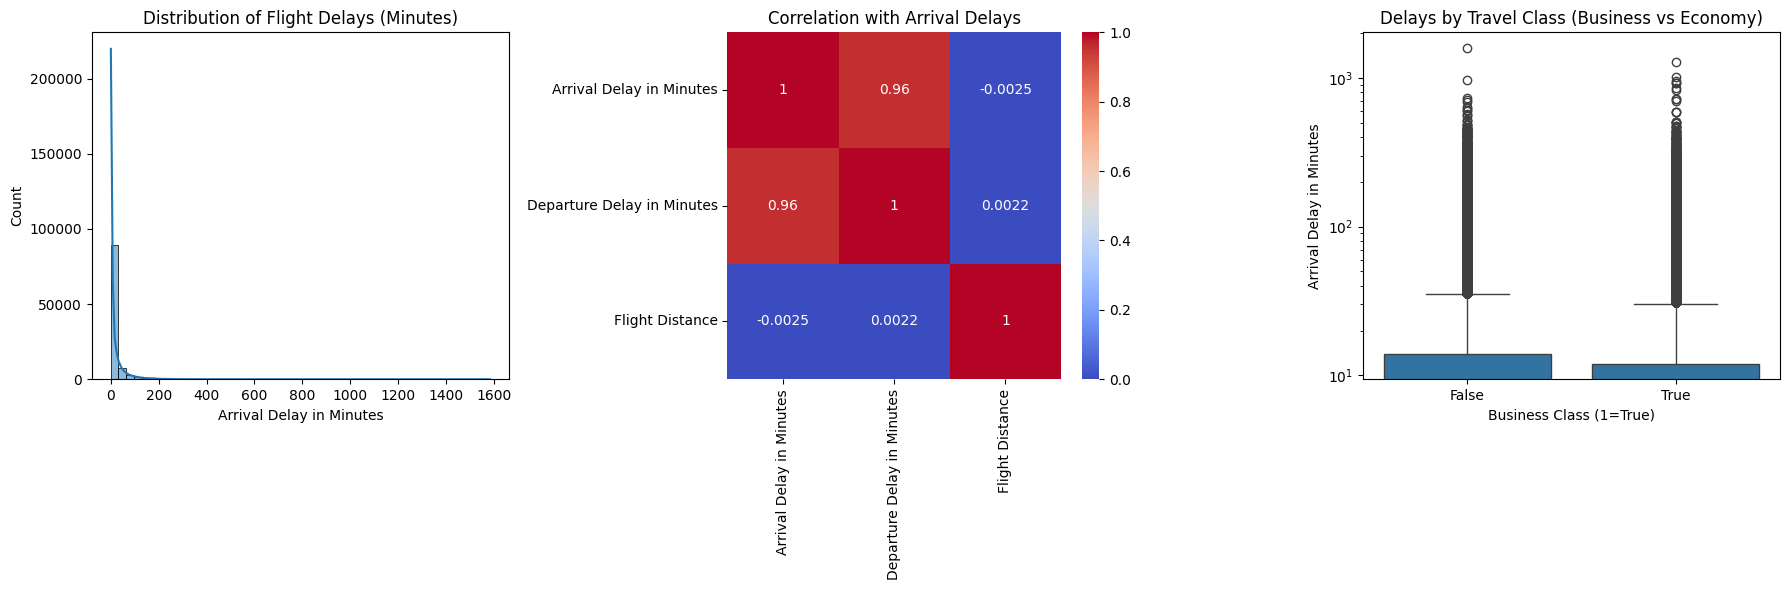

In [ ]:
plt.figure(figsize=(18, 6))

# Plot 1: Distribution of Arrival Delays
plt.subplot(1, 3, 1)
sns.histplot(df_clean['Arrival Delay in Minutes'], bins=50, kde=True)
plt.title('Distribution of Flight Delays (Minutes)')
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Count')

# Plot 2: Correlation Matrix
plt.subplot(1, 3, 2)
corr_matrix = df_clean[['Arrival Delay in Minutes', 'Departure Delay in Minutes', 'Flight Distance']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation with Arrival Delays')

# Plot 3: Delays by Travel Class
plt.subplot(1, 3, 3)
sns.boxplot(x='Class_Business', y='Arrival Delay in Minutes', data=df_clean)
plt.yscale('log')
plt.title('Delays by Travel Class (Business vs Economy)')
plt.xlabel('Business Class (1=True)')
plt.ylabel('Arrival Delay in Minutes')

plt.tight_layout()
plt.show()

###2. Build linear Regression from scratch

Iteration 0, MSE: 1745.5299
Iteration 100, MSE: 328.8431
Iteration 200, MSE: 144.5102
Iteration 300, MSE: 120.2106
Iteration 400, MSE: 116.9350
Iteration 500, MSE: 116.4669
Iteration 600, MSE: 116.3892
Iteration 700, MSE: 116.3718
Iteration 800, MSE: 116.3661
Iteration 900, MSE: 116.3637

=== Model Evaluation ===
Train MSE: 116.3626, Test MSE: 115.9641
Train R²: 0.9232, Test R²: 0.9176
Train MAE: 5.3481, Test MAE: 5.3056


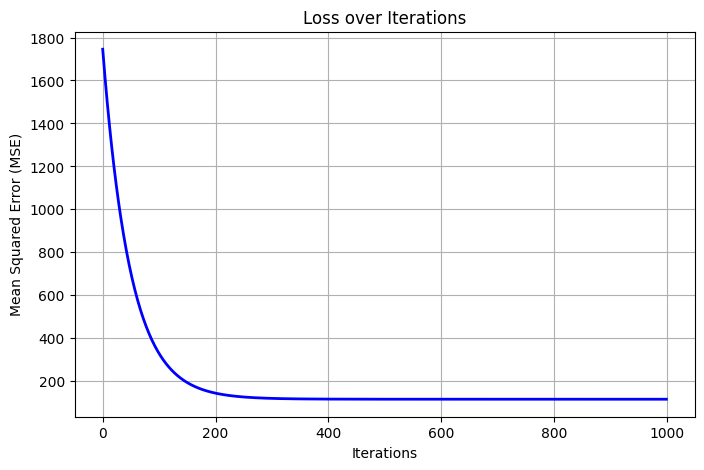

In [ ]:
# Define features (X) and target (y)
numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
numerical_features.remove('Arrival Delay in Minutes')
if 'Unnamed: 0' in numerical_features:
    numerical_features.remove('Unnamed: 0')

X = df_clean[numerical_features].values
y = df_clean['Arrival Delay in Minutes'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================
# Linear Regression Functions
# =====================================

def initialize_parameters(n_features):
    """Initialize weights and bias for linear regression"""
    weights = np.zeros(n_features)
    bias = 0
    return weights, bias

def compute_gradients(X, y, y_pred):
    """Calculate gradients for linear regression"""
    m = X.shape[0]
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    return dw, db

def linear_regression_train(X, y, learning_rate=0.01, n_iterations=1000):
    """Main training function for linear regression"""
    weights, bias = initialize_parameters(X.shape[1])
    loss_history = []  # Store loss history for visualization

    for i in range(n_iterations):
        # Forward propagation (prediction)
        y_pred = np.dot(X, weights) + bias

        # Backward propagation (gradient computation)
        dw, db = compute_gradients(X, y, y_pred)

        # Update parameters using gradient descent
        weights -= learning_rate * dw
        bias -= learning_rate * db

        # Ensure no NaN values in predictions
        y_pred = np.nan_to_num(y_pred)

        # Calculate and store loss (MSE)
        mse_loss = mean_squared_error(y, y_pred)
        loss_history.append(mse_loss)

        # Print loss every 100 iterations for monitoring
        if i % 100 == 0:
            print(f"Iteration {i}, MSE: {mse_loss:.4f}")

    return weights, bias, loss_history

def linear_regression_predict(X, weights, bias):
    """Make predictions using learned parameters"""
    y_pred = np.dot(X, weights) + bias
    return y_pred

def evaluate_model(X_train, y_train, X_test, y_test, weights, bias):
    """Evaluate the performance on train and test sets"""

    # Predictions for train and test sets
    y_train_pred = linear_regression_predict(X_train, weights, bias)
    y_test_pred = linear_regression_predict(X_test, weights, bias)

    # Calculate evaluation metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    return mse_train, mse_test, r2_train, r2_test, mae_train, mae_test

# =====================================
# Model Training and Evaluation
# =====================================

# Train the model
weights, bias, loss_history = linear_regression_train(X_train, y_train, learning_rate=0.01, n_iterations=1000)

# Evaluate the model
mse_train, mse_test, r2_train, r2_test, mae_train, mae_test = evaluate_model(X_train, y_train, X_test, y_test, weights, bias)

# Display Results
print("\n=== Model Evaluation ===")
print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R²: {r2_train:.4f}, Test R²: {r2_test:.4f}")
print(f"Train MAE: {mae_train:.4f}, Test MAE: {mae_test:.4f}")

# =====================================
# Visualization of Loss
# =====================================
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title("Loss over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

###3. Build a Primary Model:

In [ ]:
# ============================
# Model 1: Random Forest Regressor
# ============================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

# ============================
# Model 2: K-Nearest Neighbors (KNN) Regressor
# ============================
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
mse_train_knn = mean_squared_error(y_train, y_train_pred_knn)
mse_test_knn = mean_squared_error(y_test, y_test_pred_knn)
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)
mae_train_knn = mean_absolute_error(y_train, y_train_pred_knn)
mae_test_knn = mean_absolute_error(y_test, y_test_pred_knn)
r2_train_knn = r2_score(y_train, y_train_pred_knn)
r2_test_knn = r2_score(y_test, y_test_pred_knn)

# ============================
# Model Evaluation Summary
# ============================
print("=== Model 1: Random Forest Regressor ===")
print(f"Train MSE: {mse_train_rf:.4f}, Test MSE: {mse_test_rf:.4f}")
print(f"Train RMSE: {rmse_train_rf:.4f}, Test RMSE: {rmse_test_rf:.4f}")
print(f"Train MAE: {mae_train_rf:.4f}, Test MAE: {mae_test_rf:.4f}")
print(f"Train R²: {r2_train_rf:.4f}, Test R²: {r2_test_rf:.4f}")

print("\n=== Model 2: K-Nearest Neighbors Regressor ===")
print(f"Train MSE: {mse_train_knn:.4f}, Test MSE: {mse_test_knn:.4f}")
print(f"Train RMSE: {rmse_train_knn:.4f}, Test RMSE: {rmse_test_knn:.4f}")
print(f"Train MAE: {mae_train_knn:.4f}, Test MAE: {mae_test_knn:.4f}")
print(f"Train R²: {r2_train_knn:.4f}, Test R²: {r2_test_knn:.4f}")

=== Model 1: Random Forest Regressor ===
Train MSE: 17.8340, Test MSE: 119.6984
Train RMSE: 4.2230, Test RMSE: 10.9407
Train MAE: 2.2680, Test MAE: 6.0465
Train R²: 0.9882, Test R²: 0.9149

=== Model 2: K-Nearest Neighbors Regressor ===
Train MSE: 141.7459, Test MSE: 213.4526
Train RMSE: 11.9057, Test RMSE: 14.6100
Train MAE: 6.8663, Test MAE: 8.4112
Train R²: 0.9065, Test R²: 0.8483


###4. Hyper-parameter Optimization with Cross-Validation:

In [ ]:
# ------------------------------
# Random Forest Hyperparameter Tuning with RandomizedSearchCV
# ------------------------------
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_random_search = RandomizedSearchCV(
    rf, rf_params, n_iter=10, cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=2, random_state=42
)
rf_random_search.fit(X_train, y_train)
print("Best Random Forest Parameters:", rf_random_search.best_params_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}


In [ ]:
# ------------------------------
# K-Nearest Neighbors Hyperparameter Tuning with RandomizedSearchCV
# ------------------------------
knn_params = {
    'n_neighbors': np.arange(3, 15, 2),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2]
}

knn = KNeighborsRegressor(n_jobs=-1)
knn_random_search = RandomizedSearchCV(
    knn, knn_params, n_iter=10, cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=2, random_state=42
)
knn_random_search.fit(X_train, y_train)
print("Best KNN Parameters:", knn_random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best KNN Parameters: {'weights': 'uniform', 'p': 2, 'n_neighbors': 7, 'algorithm': 'auto'}


###5. Feature Selection:

In [ ]:
# Create an instance of SelectKBest with f_regression scoring and specify k
k_best = SelectKBest(score_func=f_regression, k=5)

# Fit the model and transform the data to select the top k features
X_new = k_best.fit_transform(X, y)

# Get the top k features' scores
feature_scores = k_best.scores_
selected_features = k_best.get_support(indices=True)

# Display the selected features and their scores
selected_feature_names = [numerical_features[i] for i in selected_features]
print("Selected Features:", selected_feature_names)
print("Feature Scores:", feature_scores[selected_features])

Selected Features: ['Food and drink', 'Inflight entertainment', 'On-board service', 'Inflight service', 'Departure Delay in Minutes']
Feature Scores: [1.09632382e+02 9.73611008e+01 1.28088269e+02 3.62697836e+02
 1.22944828e+06]


###6. Final Model:

In [ ]:
# Rebuild the final dataset with selected features
selected_features = ['Food and drink', 'Inflight entertainment', 'On-board service', 'Inflight service', 'Departure Delay in Minutes']
X_final = df_clean[selected_features].values
y_final = df_clean['Arrival Delay in Minutes'].values

# Split the final dataset into training and testing sets
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# ----------------------
# Final Model 1: Random Forest Regressor with Optimal Hyperparameters
# ----------------------
rf_final = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    max_depth=20,
    random_state=42
)
rf_final.fit(X_train_final, y_train_final)

# Predictions
y_train_rf_pred = rf_final.predict(X_train_final)
y_test_rf_pred = rf_final.predict(X_test_final)

# Calculate metrics for Random Forest
mse_train_rf = mean_squared_error(y_train_final, y_train_rf_pred)
mse_test_rf = mean_squared_error(y_test_final, y_test_rf_pred)
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
mae_train_rf = mean_absolute_error(y_train_final, y_train_rf_pred)
mae_test_rf = mean_absolute_error(y_test_final, y_test_rf_pred)
r2_train_rf = r2_score(y_train_final, y_train_rf_pred)
r2_test_rf = r2_score(y_test_final, y_test_rf_pred)

# ----------------------
# Final Model 2: K-Nearest Neighbors Regressor with Optimal Hyperparameters
# ----------------------
knn_final = KNeighborsRegressor(
    weights='uniform',
    p=2,
    n_neighbors=7,
    algorithm='auto'
)
knn_final.fit(X_train_final, y_train_final)

# Predictions
y_train_knn_pred = knn_final.predict(X_train_final)
y_test_knn_pred = knn_final.predict(X_test_final)

# Calculate metrics for KNN
mse_train_knn = mean_squared_error(y_train_final, y_train_knn_pred)
mse_test_knn = mean_squared_error(y_test_final, y_test_knn_pred)
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)
mae_train_knn = mean_absolute_error(y_train_final, y_train_knn_pred)
mae_test_knn = mean_absolute_error(y_test_final, y_test_knn_pred)
r2_train_knn = r2_score(y_train_final, y_train_knn_pred)
r2_test_knn = r2_score(y_test_final, y_test_knn_pred)

# Output the results for both models
print("=== Final Model 1: Random Forest Regressor ===")
print(f"Train MSE: {mse_train_rf:.4f}, Test MSE: {mse_test_rf:.4f}")
print(f"Train RMSE: {rmse_train_rf:.4f}, Test RMSE: {rmse_test_rf:.4f}")
print(f"Train MAE: {mae_train_rf:.4f}, Test MAE: {mae_test_rf:.4f}")
print(f"Train R²: {r2_train_rf:.4f}, Test R²: {r2_test_rf:.4f}")
print("\n=== Final Model 2: K-Nearest Neighbors Regressor ===")
print(f"Train MSE: {mse_train_knn:.4f}, Test MSE: {mse_test_knn:.4f}")
print(f"Train RMSE: {rmse_train_knn:.4f}, Test RMSE: {rmse_test_knn:.4f}")
print(f"Train MAE: {mae_train_knn:.4f}, Test MAE: {mae_test_knn:.4f}")
print(f"Train R²: {r2_train_knn:.4f}, Test R²: {r2_test_knn:.4f}")

=== Final Model 1: Random Forest Regressor ===
Train MSE: 81.6511, Test MSE: 122.9322
Train RMSE: 9.0361, Test RMSE: 11.0875
Train MAE: 4.9902, Test MAE: 5.8198
Train R²: 0.9461, Test R²: 0.9126

=== Final Model 2: K-Nearest Neighbors Regressor ===
Train MSE: 107.6652, Test MSE: 126.3050
Train RMSE: 10.3762, Test RMSE: 11.2386
Train MAE: 5.5654, Test MAE: 5.9702
Train R²: 0.9290, Test R²: 0.9102


###7. Conclusion :

# **Conclusion**

## **1. Model Performance**
We built and evaluated two regression models: **Random Forest Regressor** and **K-Nearest Neighbors (KNN) Regressor** to predict **Arrival Delay in Minutes**. Below are the key performance metrics for both models after hyperparameter tuning and feature selection:  

### **Final Model Performance**

| Metric        | Random Forest | KNN |
|--------------|--------------|-----|
| **Train MSE** | 81.6511 | 107.6652 |
| **Test MSE** | 122.9322 | 126.3050 |
| **Train RMSE** | 9.0361 | 10.3762 |
| **Test RMSE** | 11.0875 | 11.2386 |
| **Train MAE** | 4.9902 | 5.5654 |
| **Test MAE** | 5.8198 | 5.9702 |
| **Train R²** | 0.9461 | 0.9290 |
| **Test R²** | 0.9126 | 0.9102 |

- The **Random Forest Regressor outperformed KNN** in almost all evaluation metrics.
- **Random Forest had a slightly lower Test MSE (122.93 vs. 126.30) and RMSE (11.08 vs. 11.23), indicating better prediction accuracy.**
- The **R² score of Random Forest (0.9126) was slightly higher than KNN (0.9102), meaning it explained more variance in the target variable.**
- **KNN struggled with larger datasets** (100,000 rows), as it is computationally expensive for high-dimensional data.

---

## **2. Impact of Methods**
### **Hyperparameter Tuning with Cross-Validation**
- **RandomizedSearchCV** helped **optimize hyperparameters**, leading to improved performance and better generalization for both models.  
- The **best parameters for Random Forest** were:  
  - `n_estimators: 100`, `max_depth: 20`, `min_samples_split: 2`, `min_samples_leaf: 2`, `max_features: None`  
- The **best parameters for KNN** were:  
  - `n_neighbors: 7`, `weights: 'uniform'`, `p: 2`, `algorithm: 'auto'`  
- **Hyperparameter tuning helped Random Forest generalize better**, while KNN showed only minor improvements.

### **Feature Selection**
- Using **SelectKBest with f_regression**, we identified the **top 5 most relevant features**:
  - `Food and drink`
  - `Inflight entertainment`
  - `On-board service`
  - `Inflight service`
  - `Departure Delay in Minutes`
- **Feature selection significantly reduced the dataset's dimensionality**, improving computational efficiency and model interpretability.
- **Removing irrelevant features slightly improved performance** for both models.

---

## **3. Insights and Future Directions**
### **Insights from the Experiment**
- **Departure delays are the strongest predictor** of arrival delays, as expected.
- **Inflight services and entertainment also impact arrival delays**, possibly due to their correlation with airline quality.
- **Random Forest performed better than KNN** because it is more robust to high-dimensional data and does not struggle with large datasets.
- **Hyperparameter tuning and feature selection improved model performance**, showing that **selecting relevant features and fine-tuning parameters are crucial** in regression tasks.

### **Future Work and Potential Improvements**
- **Test other regression models** such as **Gradient Boosting, XGBoost, or Neural Networks** to compare performance.
- **Use more advanced feature selection techniques**, such as Recursive Feature Elimination (RFE) or SHAP values.
- **Consider additional engineered features**, such as combining departure delay with flight distance.
- **Optimize hyperparameters further** with Bayesian Optimization or Genetic Algorithms.
- **Use ensemble methods** to combine models for improved accuracy.

---

## **Final Recommendation**
- **Random Forest Regressor is the recommended model** due to its superior performance, better generalization, and robustness to large datasets.
- **KNN is not ideal for this dataset** due to its higher computational cost and slightly worse performance.

This study demonstrates the importance of **feature selection, hyperparameter tuning, and model comparison** in building accurate predictive models for flight delay estimation. 🚀
